In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model
import numpy as np

# Create an empty graph
G = nx.Graph()

In [2]:
# Ajout des nœuds
G.add_nodes_from(['Maths', 'Physique', 'Info', 'Chimie', 'Algo', 'BDD', 'SVT', 'Anglais'])

# Ajout des narêtes
G.add_edges_from([('Maths', 'Physique'), ('Maths', 'Info'), ('Maths', 'Chimie'), ('Physique', 'Chimie'), ('Physique', 'SVT'), ('Info', 'Algo'), ('Info', 'BDD'), 
                 ('Chimie', 'SVT'), ('Algo',  'BDD'), ('Algo', 'Maths'), ('Anglais', 'Maths'), ('Anglais', 'Info')])

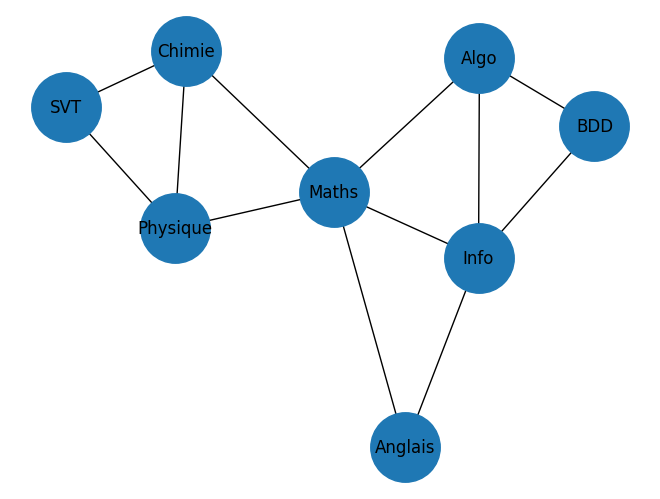

In [3]:
nx.draw(G, with_labels=True, node_size=2500)  # Tracé du graphe
plt.show()

In [4]:
# Model
model = cp_model.CpModel()

matieres = list(G.nodes())
conflits = list(G.edges())
nb_max_creneaux = len(matieres) 

# Variables de décision
x = {}
for i in matieres:
    for j in range(nb_max_creneaux):
        x[i, j] = model.NewBoolVar(f'x_{i}_{j}')


y = {}
for j in range(nb_max_creneaux):
    y[j] = model.NewBoolVar(f'y_{j}')


# Contraintes
for i in matieres:
    model.Add(sum(x[i,j] for j in range(nb_max_creneaux)) == 1)

for (i1, i2) in conflits:
    for j in range(nb_max_creneaux):
        model.Add(x[i1, j] + x[i2, j] <= 1)

for i in matieres:
    for j in range(nb_max_creneaux):
        model.Add(x[i, j] <= y[j])

# Fonction objectif
model.minimize(sum(y[j] for j in range(nb_max_creneaux)))

# résolution
solver = cp_model.CpSolver()
status = solver.solve(model)

if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print(f"Solution trouvée :\n")
    color_map_dict = {}
    for i in matieres:
        for j in range(nb_max_creneaux):
            if solver.Value(x[i, j]) == 1:
                color_map_dict[i] = j 
                print(f"La matière {i} est placée au créneau {j}")
else:
    print("Aucune solution n'a été trouvée.")
    
creneaux_utilises = sorted(set(color_map_dict.values()))
remap = {ancien: nouveau for nouveau, ancien in enumerate(creneaux_utilises)}
color_map_dict = {matiere: remap[creneau] for matiere, creneau in color_map_dict.items()}
print("\nAprès remappage :")
for i, j in color_map_dict.items():
    print(f"La matière {i} est placée au créneau {j}")

Solution trouvée :

La matière Maths est placée au créneau 0
La matière Physique est placée au créneau 1
La matière Info est placée au créneau 7
La matière Chimie est placée au créneau 7
La matière Algo est placée au créneau 1
La matière BDD est placée au créneau 0
La matière SVT est placée au créneau 0
La matière Anglais est placée au créneau 1

Après remappage :
La matière Maths est placée au créneau 0
La matière Physique est placée au créneau 1
La matière Info est placée au créneau 2
La matière Chimie est placée au créneau 2
La matière Algo est placée au créneau 1
La matière BDD est placée au créneau 0
La matière SVT est placée au créneau 0
La matière Anglais est placée au créneau 1


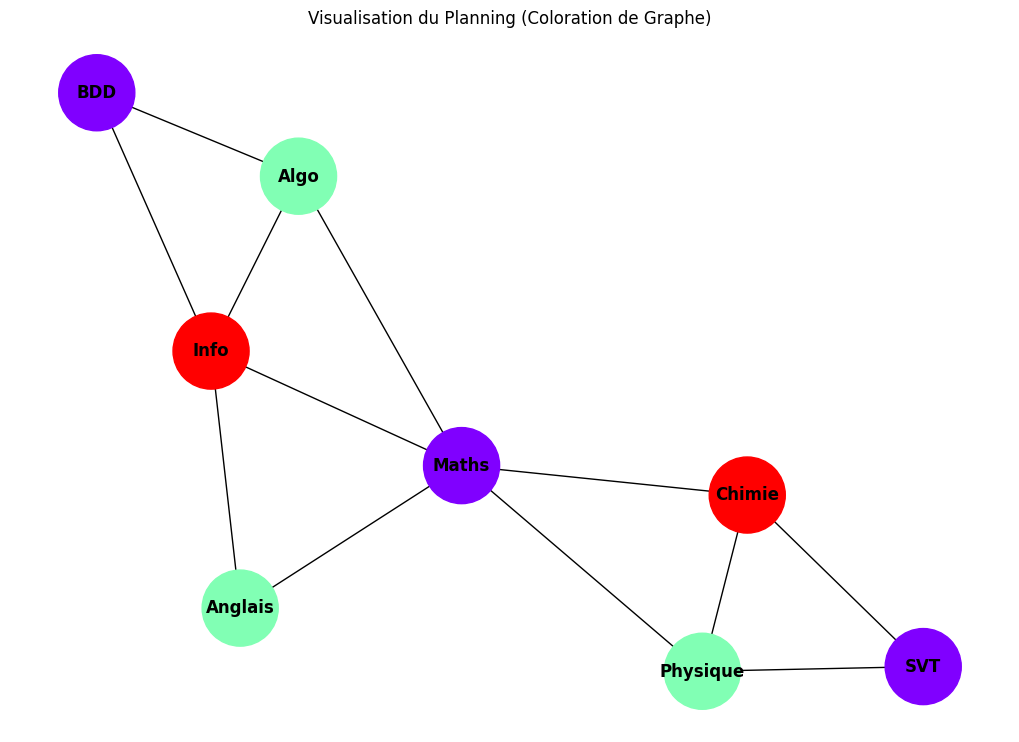

In [5]:
# 1. Créer le graphe
G = nx.Graph()
G.add_nodes_from(matieres)
G.add_edges_from(conflits)

# 2. Extraire les couleurs dans l'ordre des nœuds de G
node_colors = [color_map_dict[node] for node in G.nodes()]

# 3. Dessiner
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G) # Positionnement automatique des nœuds

nx.draw(G, pos, 
        with_labels=True, 
        node_color=node_colors, 
        node_size=3000, 
        cmap=plt.cm.rainbow, 
        font_weight='bold')

plt.title("Visualisation du Planning (Coloration de Graphe)")
plt.show()
